#### Banking Clients Exploritary Data Analysis
#### Author  : Aleksandra Vislova




### Step 1: Loading data


In [0]:
# Display all data from the banking table
display(spark.table("workspace.default.banking"))
display(spark.table("workspace.default.gender"))
display(spark.table("workspace.default.banking_realtionships"))
display(spark.table("workspace.default.investment_advisiors"))


Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
IND81288,Raymond Mills,24,34324,2019-05-06,Anthony Torres,American,Safety Technician IV,High,Jade,75384.77,17677.95,1,484.54,776242.92,1485828.64,603617.88,607332.46,12249.96,1134475.3,1,2,1,1,1
IND65833,Julia Spencer,23,42205,2001-12-10,Jonathan Hawkins,African,Software Consultant,High,Jade,289834.31,17398.92,1,2256.88,1270615.43,641482.79,229521.37,344635.16,61162.31,2000526.1,1,3,2,1,2
IND47499,Stephen Murray,27,7314,2010-01-25,Anthony Berry,European,Help Desk Operator,High,Gold,169935.23,42825.9,2,4568.74,1052715.84,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
IND72498,Virginia Garza,40,34594,2019-03-28,Steve Diaz,American,Geologist II,Mid,Silver,356808.11,5473.15,2,4205.0,121195.06,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
IND60181,Melissa Sanders,46,41269,2012-07-20,Shawn Long,American,Assistant Professor,Mid,Platinum,130711.68,48077.6,1,3779.49,1048301.95,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5
IND78532,Samuel Hudson,23,13204,2019-02-07,Douglas Tucker,American,Help Desk Technician,High,Silver,118326.96,6028.2,2,5148.56,601902.5,1307269.41,745627.74,238310.37,15615.18,1556031.06,1,2,1,1,6
IND95683,Timothy Alexander,46,42910,2002-06-02,Douglas Tucker,Asian,Account Coordinator,High,Gold,57336.47,13929.16,1,959.9,208909.69,41200.18,60588.5,24639.33,3045.78,154111.62,1,1,1,2,7
IND40785,Carl Martin,78,6127,2000-11-03,Steve Diaz,European,Automation Specialist II,Mid,Gold,65125.8,31077.8,1,4576.58,1140704.8,156983.13,53889.73,46813.78,51979.19,1171456.68,0,2,2,2,8
IND13570,Philip Day,67,32656,2015-04-07,Bruce Butler,Asian,Software Test Engineer II,High,Silver,87849.47,9385.35,1,78.62,803444.46,1242347.22,328334.62,279528.12,27125.28,464560.28,0,1,2,2,9
IND53299,Jason Sims,51,28340,1995-11-20,Joe Price,European,Geologist III,Mid,Silver,65369.36,27364.8,3,4836.86,60027.9,317246.67,111532.03,115869.39,48043.52,908583.94,2,1,3,1,10


GenderId,Gender
1,Male
2,Female


BRId,Banking Relationship
1,Retail
2,Institutional
3,Private Bank
4,Commercial


IAId,Investment Advisor
1,Victor Dean
2,Jeremy Porter
3,Ernest Knight
4,Eric Shaw
5,Kevin Kim
6,Victor Rogers
7,Eugene Cunningham
8,Joe Carroll
9,Steve Sanchez
10,Lawrence Sanchez


In [0]:
# Load the tables as Spark DataFrame
df_clients = spark.table("workspace.default.banking")
df_gender = spark.table("workspace.default.gender")
df_realtionships = spark.table("workspace.default.banking_realtionships")
df_advisors = spark.table("workspace.default.investment_advisiors")

df_clients.printSchema()
df_gender.printSchema()
df_realtionships.printSchema()
df_advisors.printSchema()

root
 |-- Client ID: string (nullable = true)
 |-- Name: string (nullable = true)
 |-- Age: long (nullable = true)
 |-- Location ID: long (nullable = true)
 |-- Joined Bank: date (nullable = true)
 |-- Banking Contact: string (nullable = true)
 |-- Nationality: string (nullable = true)
 |-- Occupation: string (nullable = true)
 |-- Fee Structure: string (nullable = true)
 |-- Loyalty Classification: string (nullable = true)
 |-- Estimated Income: double (nullable = true)
 |-- Superannuation Savings: double (nullable = true)
 |-- Amount of Credit Cards: long (nullable = true)
 |-- Credit Card Balance: double (nullable = true)
 |-- Bank Loans: double (nullable = true)
 |-- Bank Deposits: double (nullable = true)
 |-- Checking Accounts: double (nullable = true)
 |-- Saving Accounts: double (nullable = true)
 |-- Foreign Currency Account: double (nullable = true)
 |-- Business Lending: double (nullable = true)
 |-- Properties Owned: long (nullable = true)
 |-- Risk Weighting: long (nullabl

In [0]:
# Join with lookup tables to add descriptive columns
from pyspark.sql.functions import col

# Perform left joins to add Gender, Banking Relationship, and Investment Advisor columns
df = df_clients \
    .join(df_gender, on="GenderId", how="left") \
    .join(df_realtionships, on="BRId", how="left") \
    .join(df_advisors, on="IAId", how="left")

# Reorder columns to show new descriptive fields after their ID counterparts
column_order = [
    'Client ID', 'Name', 'Age', 'Location ID', 'Joined Bank', 'Banking Contact',
    'Nationality', 'Occupation', 'Fee Structure', 'Loyalty Classification',
    'Estimated Income', 'Superannuation Savings', 'Amount of Credit Cards',
    'Credit Card Balance', 'Bank Loans', 'Bank Deposits', 'Checking Accounts',
    'Saving Accounts', 'Foreign Currency Account', 'Business Lending',
    'Properties Owned', 'Risk Weighting',
    'BRId', 'Banking Relationship',
    'GenderId', 'Gender',
    'IAId', 'Investment Advisor'
]

df = df.select(column_order)
display(df.select('Client ID', 'Name', 'GenderId', 'Gender', 'BRId', 'Banking Relationship', 'IAId', 'Investment Advisor').limit(10))

Client ID,Name,GenderId,Gender,BRId,Banking Relationship,IAId,Investment Advisor
IND81288,Raymond Mills,1,Male,1,Retail,1,Victor Dean
IND65833,Julia Spencer,1,Male,2,Institutional,2,Jeremy Porter
IND47499,Stephen Murray,2,Female,3,Private Bank,3,Ernest Knight
IND72498,Virginia Garza,1,Male,4,Commercial,4,Eric Shaw
IND60181,Melissa Sanders,2,Female,1,Retail,5,Kevin Kim
IND78532,Samuel Hudson,1,Male,1,Retail,6,Victor Rogers
IND95683,Timothy Alexander,2,Female,1,Retail,7,Eugene Cunningham
IND40785,Carl Martin,2,Female,2,Institutional,8,Joe Carroll
IND13570,Philip Day,2,Female,2,Institutional,9,Steve Sanchez
IND53299,Jason Sims,1,Male,3,Private Bank,10,Lawrence Sanchez


### Step 2: EDA

In [0]:
print(f"Number of columns: {len(df.columns)}")
print(f"Number of rows: {df.count()}")

display(df.describe())


Number of columns: 28
Number of rows: 3000


summary,Client ID,Name,Age,Location ID,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,Banking Relationship,GenderId,Gender,IAId,Investment Advisor
count,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000
mean,null,null,51.03966666666667,21563.323,null,null,null,null,null,171305.0342633338,25531.599673333312,1.4636666666666667,3176.206943333331,591386.1554866654,671560.1939233337,321092.94912666606,232908.3534833335,29883.52999333338,866759.8084066679,1.5186666666666666,2.2493333333333334,2.5593333333333335,null,1.504,null,10.425333333333333,null
stddev,null,null,19.85476006036269,12462.273016652493,null,null,null,null,null,111935.80820930158,16259.950769534422,0.6763867645368546,2497.0947090086543,457557.0363338233,645716.8568753367,282079.5538925877,230007.77749790717,23109.924009821396,641230.3218226124,1.1021447862836422,1.1311908561953348,1.007712616338584,null,0.5000673512490724,null,5.988242193700283,null
min,IND12601,Aaron Bryant,17,12,Adam Hernandez,African,Account Coordinator,High,Gold,15919.48,1482.03,1,1.17,0.0,0.0,0.0,0.0,45.0,0.0,0,1,1,Commercial,1,Female,1,Carl Anderson
max,IND99980,Willie Wheeler,85,43369,Victor Ramos,European,Web Developer IV,Mid,Silver,522330.26,75963.9,3,13991.99,2667556.66,3890598.08,1969923.08,1724118.36,124704.87,3825961.94,3,5,4,Retail,2,Male,22,Victor Rogers


 Check for duplicated rows 

In [0]:
total_rows = df.count()
distinct_rows = df.distinct().count()


print(f"Total rows: {total_rows}")
print(f"Distinct rows: {distinct_rows}")

Total rows: 3000
Distinct rows: 3000


###  Step 3: Categorical Variables Analysis

##### Count of distinct values for Nominal and Ordianl Variables relevant for analysis

In [0]:
categorical_cols = [
    'Nationality', 'Occupation', 'Gender', 'Fee Structure', 'Risk Weighting',
    'Amount of Credit Cards', 'Loyalty Classification', 'IAId',
    'Properties Owned', 'Banking Relationship'
]

for column in categorical_cols:
    distinct_count = df.select(column).distinct().count()
    print(f"{column}: {distinct_count} distinct values")

Nationality: 5 distinct values
Occupation: 195 distinct values
Gender: 2 distinct values
Fee Structure: 3 distinct values
Risk Weighting: 5 distinct values
Amount of Credit Cards: 3 distinct values
Loyalty Classification: 4 distinct values
IAId: 22 distinct values
Properties Owned: 4 distinct values
Banking Relationship: 4 distinct values


In [0]:

for col_name in categorical_cols:
    print(f"\n{col_name}:")
    freq_table = df.groupBy(col_name).count().orderBy(col_name)
    display(freq_table)
    
    distinct_count = df.select(col_name).distinct().count()
    print(f"Distinct values: {distinct_count}")


Nationality:


Nationality,count
African,176
American,507
Asian,754
Australian,254
European,1309


Distinct values: 5

Occupation:


Occupation,count
Account Coordinator,24
Account Executive,17
Account Representative I,20
Account Representative II,16
Account Representative III,15
Account Representative IV,15
Accountant I,18
Accountant II,18
Accountant III,18
Accountant IV,13


Distinct values: 195

Gender:


...

Distinct values: 22

Properties Owned:


Properties Owned,count
0,705
1,776
2,777
3,742


Distinct values: 4

Banking Relationship:


Banking Relationship,count
Commercial,493
Institutional,495
Private Bank,1352
Retail,660


Distinct values: 4


#### Adding  column: 

- Income Category: based on numerical income data

In [0]:

# Create income category column 
from pyspark.sql.functions import when, col, min as spark_min, max as spark_max

# Calculate min and max for binning
income_stats = df.select(
    spark_min(col("Estimated Income")).alias("min_income"),
    spark_max(col("Estimated Income")).alias("max_income")
).collect()[0]

min_income = income_stats["min_income"]
max_income = income_stats["max_income"]
bin_width = (max_income - min_income) / 3

low_threshold = min_income + bin_width
high_threshold = min_income + (2 * bin_width)

df = df.withColumn(
    "IncomeCategory",
    when(col("Estimated Income") <= low_threshold, "Low")
    .when(col("Estimated Income") <= high_threshold, "Medium")
    .otherwise("High")
)

print("Income Category Distribution:")
display(df.groupBy("IncomeCategory").count().orderBy("IncomeCategory"))

Income Category Distribution:


IncomeCategory,count
High,251
Low,1888
Medium,861


### Add categorical column for Risk Weighting

- Risk Weightning : based on category (1-5)


In [0]:

from pyspark.sql.functions import when, col

# Map numerical risk scores (1-5) to categorical labels
df = df.withColumn(
    "RiskCategory",
    when(col("Risk Weighting") == 1, "Very Low")
    .when(col("Risk Weighting") == 2, "Low")
    .when(col("Risk Weighting") == 3, "Medium")
    .when(col("Risk Weighting") == 4, "High")
    .when(col("Risk Weighting") == 5, "Very High")
    .otherwise("Unknown")
)

print("Risk Category Distribution:")
display(df.groupBy("Risk Weighting", "RiskCategory").count().orderBy("Risk Weighting"))

Risk Category Distribution:


Risk Weighting,RiskCategory,count
1,Very Low,836
2,Low,1222
3,Medium,460
4,High,322
5,Very High,160


### Step 4: Numerical Variables Analysis

Descriptive statistics for continuous numerical variables

In [0]:

from pyspark.sql.functions import mean, stddev, min as spark_min, max as spark_max, percentile_approx

numerical_cols = [
    'Age', 'Estimated Income', 'Superannuation Savings', 'Credit Card Balance',
    'Bank Loans', 'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
    'Foreign Currency Account', 'Business Lending'
]
display(df.select(numerical_cols).describe())

summary,Age,Estimated Income,Superannuation Savings,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending
count,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000
mean,51.03966666666667,171305.0342633338,25531.599673333312,3176.206943333331,591386.1554866654,671560.1939233337,321092.94912666606,232908.3534833335,29883.52999333338,866759.8084066679
stddev,19.85476006036269,111935.80820930158,16259.950769534422,2497.0947090086543,457557.0363338233,645716.8568753367,282079.5538925877,230007.77749790717,23109.924009821396,641230.3218226124
min,17,15919.48,1482.03,1.17,0.0,0.0,0.0,0.0,45.0,0.0
max,85,522330.26,75963.9,13991.99,2667556.66,3890598.08,1969923.08,1724118.36,124704.87,3825961.94


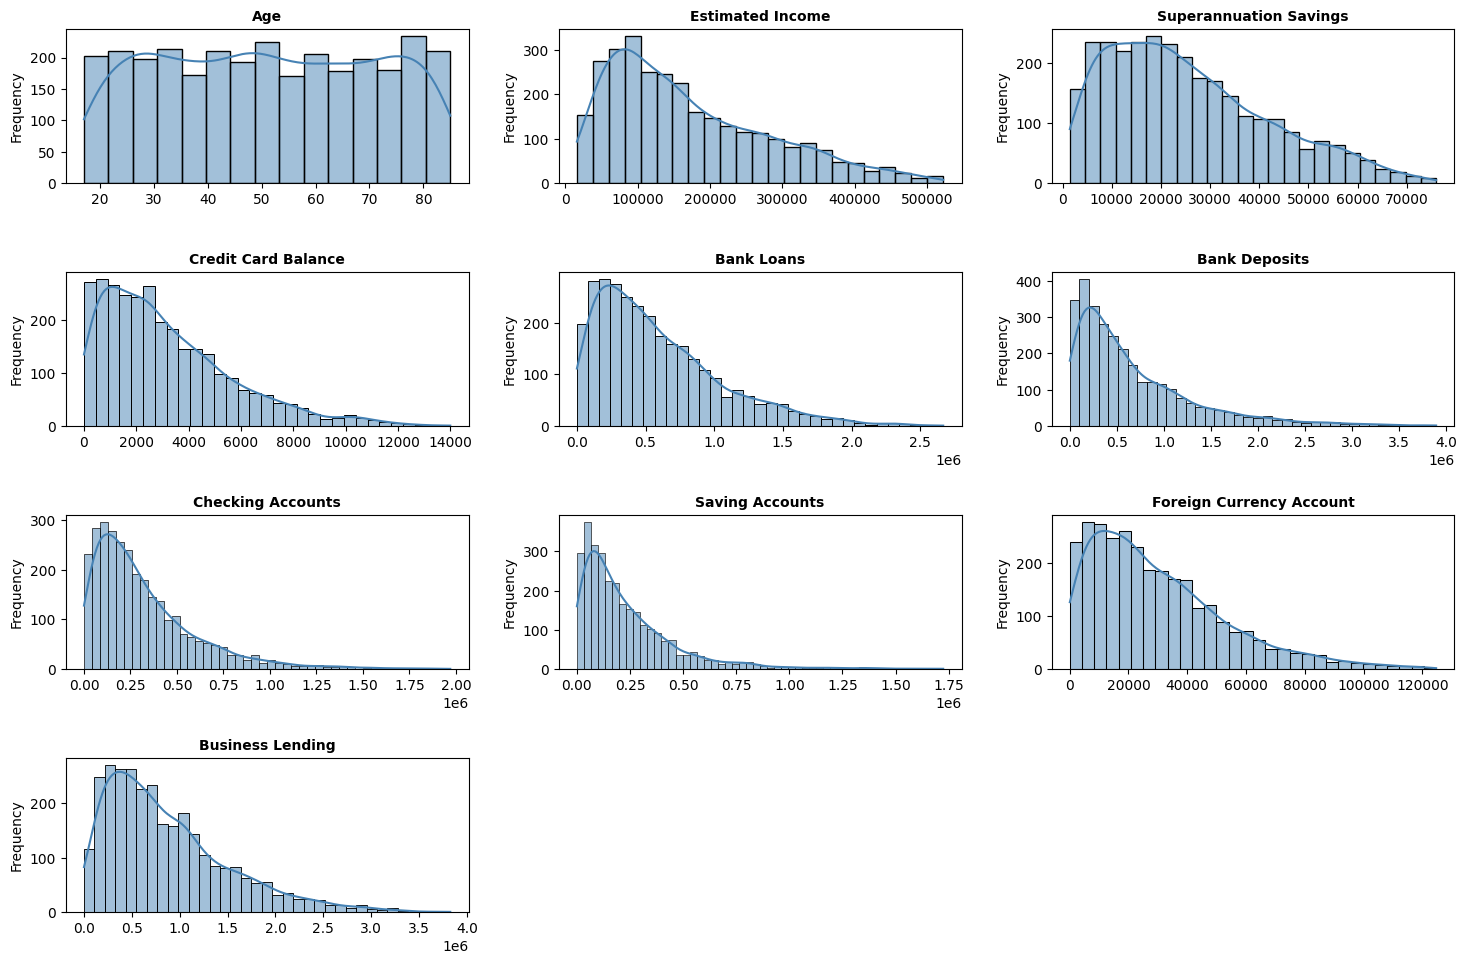

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

df_pandas = df.select(numerical_cols).toPandas()

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i+1)
    sns.histplot(df_pandas[col], kde=True, color='steelblue')
    plt.title(col, fontsize=10, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Frequency')

plt.tight_layout(pad=2.0) 
plt.show()

**Age:** fairly evenly distributed across the displayed range, with no strong concentration in a single age group.

**Estimated Income:** right-skewed, with most clients clustered in the lower to mid income range and fewer very high-income clients.

**Superannuation Savings:** right-skewed, showing many clients with moderate savings and a long tail toward higher balances.

**Credit Card Balance:** heavily right-skewed, with most balances concentrated at the lower end and fewer large balances.

**Bank Loans:** right-skewed, with most clients carrying smaller loan amounts and a small number holding very large loans.

**Bank Deposits:** strongly right-skewed, indicating that many clients keep modest deposits while only a few have very high deposit amounts.

**Checking Accounts:** strongly right-skewed, with most account balances concentrated at lower values and a long upper tail.

**Saving Accounts:** strongly right-skewed, showing that most balances are small and only a few are relatively large.

**Foreign Currency Account:** right-skewed, with most clients holding lower balances and a decreasing frequency as values rise.

**Business Lending:** right-skewed, with most clients having smaller lending amounts and relatively few large exposures.



## interpretation:

This EDA shows that the banking dataset is dominated by right-skewed financial variables, meaning most clients have relatively low to moderate balances while a smaller group holds much larger amounts. 

Age is more evenly spread, but income, savings, deposits, loans, and lending products all show clear concentration at the lower end, which suggests a customer base with a few high-value outliers.

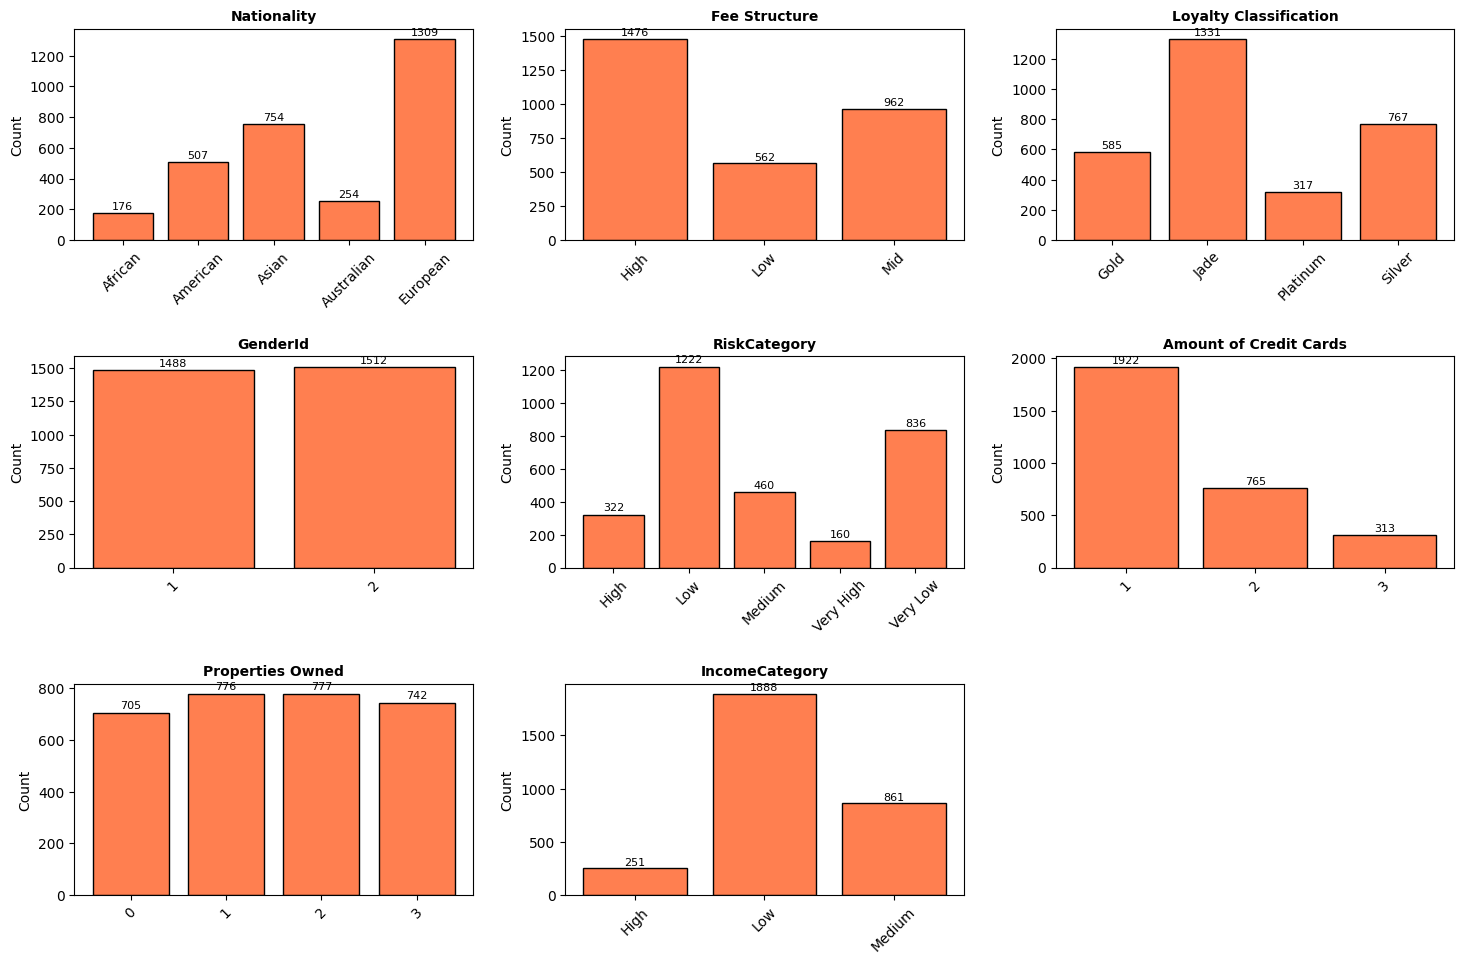

In [0]:
# Select key categorical columns for visualization
import matplotlib.pyplot as plt

cat_cols_viz = ['Nationality', 'Fee Structure', 'Loyalty Classification', 
                'GenderId', 'RiskCategory', 'Amount of Credit Cards', 
                'Properties Owned', 'IncomeCategory']

# Calculate value counts for each categorical column
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols_viz):
    counts_df = df.groupBy(col).count().orderBy(col).toPandas()
    
    axes[i].bar(counts_df[col].astype(str), counts_df['count'], color='coral', edgecolor='black')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
    for j, v in enumerate(counts_df['count']):
        axes[i].text(j, v + 10, str(v), ha='center', va='bottom', fontsize=8)


axes[8].axis('off')

plt.tight_layout(pad=2.0)
plt.show()

**Nationality**: uneven distribution European clients are the largest group by a wide margin, while African and Australian clients are much smaller.

**Fee Structure:** concentrated in the High category, with Mid next and Low the smallest.

**Loyalty Classification:** led by Jade, followed by Silver, while Platinum is the least common.

**GenderId:**  nearly balanced, suggesting no major gender imbalance in the sample.

**RiskCategory:** peaks at level 2, then drops steadily toward higher levels, which suggests a right-skewed distribution.

**Amount of Credit Cards**: mostly 1 card, with fewer clients holding 2 or 3.

**Properties Owned:** fairly evenly spread across 0 to 3, with a slight concentration around 1–2 properties.

**IncomeCategory:** dominated by Low income, with Medium next and High much less frequent.



##interpretation: 

This EDA reveals that the banking dataset is moderately imbalanced across several key categorical fields, with European clients,

low-income customers, and high fee structures forming the largest segments. Loyalty and risk profiles are also unevenly distributed, 

indicating distinct customer clusters that may be important for segmentation and product targeting.


### Step 5: Correlation Analysis

In [0]:
# Calculate correlation matrix for numerical variables
import pandas as pd
import numpy as np

df_numeric_pandas = df.select(numerical_cols).toPandas()
corr_df = df_numeric_pandas.corr()

print("Correlation Matrix:")
for i in range(len(numerical_cols)):
    for j in range(i+1, len(numerical_cols)):
        corr_value = corr_df.iloc[i, j]
        if abs(corr_value) > 0.5:
            print(f"{numerical_cols[i]}, {numerical_cols[j]}: {corr_value:.3f}")

Correlation Matrix:
Bank Deposits, Checking Accounts: 0.844
Bank Deposits, Saving Accounts: 0.755


### Step 6: Temporal Analysis - Customer Acquisition

In [0]:
# Temporal analysis: Customer acquisition over time
from pyspark.sql.functions import year, month, quarter, count, col

# Add time-based columns
df_temporal = df.withColumn("join_year", year(col("Joined Bank"))) \
                .withColumn("join_month", month(col("Joined Bank"))) \
                .withColumn("join_quarter", quarter(col("Joined Bank")))

print("\nCustomers by Year:")
display(df_temporal.groupBy("join_year").count().orderBy("join_year"))

print("\nCustomers by Quarter:")
display(df_temporal.groupBy("join_year", "join_quarter") \
        .count() \
        .orderBy("join_year", "join_quarter"))

# Calculate customer tenure (days since joining)
from pyspark.sql.functions import current_date, datediff

df_tenure = df.withColumn("tenure_days", datediff(current_date(), col("Joined Bank")))

print("\nCustomer Tenure Statistics:")
display(df_tenure.select("tenure_days").describe())


Customers by Year:


join_year,count
1995,97
1996,109
1999,101
2000,99
2001,106
2002,110
2003,98
2004,106
2005,119
2006,112



Customers by Quarter:


join_year,join_quarter,count
1995,1,22
1995,2,32
1995,3,21
1995,4,22
1996,1,28
1996,2,24
1996,3,26
1996,4,31
1999,1,25
1999,2,17



Customer Tenure Statistics:


summary,tenure_days
count,3000
mean,5804.997666666667
stddev,2845.7454205639656
min,1649
max,11508


### Step 7: Bivariate Analysis - Key Relationships

In [0]:
# Bivariate Analysis: Categorical vs Numerical
from pyspark.sql.functions import avg, sum as spark_sum


# 1. Income by Gender
print("\n1. Average Income by Gender:")
display(df.groupBy("GenderId") \
        .agg(avg("Estimated Income").alias("Avg_Income"),
             count("*").alias("Count")) \
        .orderBy("GenderId"))

# 2. Financial metrics by Loyalty Classification
print("\n2. Financial Metrics by Loyalty Classification:")
display(df.groupBy("Loyalty Classification") \
        .agg(avg("Estimated Income").alias("Avg_Income"),
             avg("Bank Deposits").alias("Avg_Deposits"),
             avg("Bank Loans").alias("Avg_Loans"),
             count("*").alias("Count")) \
        .orderBy("Loyalty Classification"))

# 3. Products by Risk Category
print("\n3. Average Products Owned by Risk Category:")
display(df.groupBy("RiskCategory") \
        .agg(avg("Amount of Credit Cards").alias("Avg_Credit_Cards"),
             avg("Properties Owned").alias("Avg_Properties"),
             count("*").alias("Count")) \
        .orderBy("RiskCategory"))

# 4. Financial products by Nationality
print("\n4. Financial Metrics by Nationality:")
display(df.groupBy("Nationality") \
        .agg(count("*").alias("Count"),
             avg("Estimated Income").alias("Avg_Income"),
             avg("Bank Deposits").alias("Avg_Deposits"),
             avg("Bank Loans").alias("Avg_Loans")) \
        .orderBy("Nationality"))


1. Average Income by Gender:


GenderId,Avg_Income,Count
1,175379.0737365589,1488
2,167295.66208333327,1512



2. Financial Metrics by Loyalty Classification:


Loyalty Classification,Avg_Income,Avg_Deposits,Avg_Loans,Count
Gold,167876.14871794873,664384.5795213674,574376.3696923082,585
Jade,172418.944673178,696576.8405710002,605675.7975432005,1331
Platinum,163760.1782018928,611699.4241640376,564806.0747634068,317
Silver,175105.55924380705,658361.2913820088,590547.9504041723,767



3. Average Products Owned by Risk Category:


RiskCategory,Avg_Credit_Cards,Avg_Properties,Count
High,1.4130434782608696,1.5093167701863355,322
Low,1.4435351882160392,1.504909983633388,1222
Medium,1.4847826086956522,1.4869565217391305,460
Very High,1.45,1.625,160
Very Low,1.5035885167464116,1.5394736842105263,836



4. Financial Metrics by Nationality:


Nationality,Count,Avg_Income,Avg_Deposits,Avg_Loans
African,176,177704.19693181815,687868.2961363635,569144.5368181816
American,507,163767.324970414,661341.7265088762,603605.2828994085
Asian,754,170775.9557824935,683437.5629442967,578497.8508885943
Australian,254,165291.31759842514,665504.3761811022,606921.4742519683
European,1309,174835.80216959506,667658.8787624148,594053.2586096255
